# 📊 Module 11 · Integrated Application — Student Version
### Course: Python from Scratch for Data Analysis

**Prerequisites:** Modules 1–10

---

### What this notebook is

This is your **final project**.
You will apply everything you have learned — loading, cleaning, analysis, visualization,
and statistics — to a real-world educational dataset.

There is no worked example here. You write the code.
Use your previous notebooks (M6–M10) as references when you need syntax reminders.

**Delivery:** complete all sections and bring this notebook to your next session.
We will review your findings together.

---

### Checklist before you deliver

- [ ] Block 1 — exploration (4 code cells + observation)
- [ ] Block 2 — cleaning (rename, derived columns, decision log)
- [ ] Block 3 — 4 charts, each with a printed statistic, title, and axis labels
- [ ] Block 4 — written conclusions (all 5 sections)
- [ ] All cells run without errors from top to bottom

---

## 📥 Step 0 — Download the dataset

**Dataset:** *Predict Students’ Dropout and Academic Success*
**Source:** UCI Machine Learning Repository (CC BY 4.0)
**Size:** 4,424 students × 37 columns

---

**Option A — Direct link (no account needed):**
1. Go to: `https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success`
2. Click **Download** → unzip → find `data.csv`.
3. Rename it **`students.csv`** and put it in the `module11/` folder.

**Option B — Kaggle:**
1. Go to: `https://www.kaggle.com/datasets/thedevastator/higher-education-predictors-of-student-retention`
2. Download → unzip → rename CSV to `students.csv` → put it in `module11/`.

> Run cells top to bottom once the file is in place.

---

## 🔷 Setup — run this cell first (provided)

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.read_csv

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

In [23]:
# Provided: the UCI file uses semicolons as separators.
df_raw = pd.read_csv("students.csv", sep=";")

print(f"Loaded: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
df_raw.head(3)

Loaded: 4424 rows × 37 columns


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout


> **FileNotFoundError?** Make sure `students.csv` is inside `module11/`, next to this notebook.
> If your file uses commas, change `sep=";"` to `sep=","`.

---

## 🔷 Block 0 — Project Plan

### Apply the 5-step process to the whole project

Before writing a single line of code, answer these questions in writing:

| Step | Your answer |
|------|-------------|
| 1. Read | What does each column represent? (Scroll through `df_raw.columns`) |
| 2. Identify | Which columns will help answer your three questions? |
| 3. Decompose | What are the four blocks of work? |
| 4. Pseudocode | One sentence per block: what will you do? |
| 5. Translate | Python, block by block (the rest of this notebook) |

---

### Your three analytical questions

You will answer these three questions in Block 3:

1. **Outcome distribution** — How many students dropped out vs graduated vs enrolled?
2. **Scholarship effect** — Do scholarship holders have a lower dropout rate?
3. **Academic performance** — Do students who graduate have higher first-semester grades?

You will also **choose and answer your own question** (Chart 4).

---

## 🔷 Block 1 — Explore the Raw Data

### Rule: explore before you touch

Never clean or transform data before understanding it.
Your first look must answer:
- What are the columns and their types?
- How many rows? Any nulls?
- What are the possible values of the **Target** column?

**Hint:** use `.info()`, `.describe()`, `.value_counts()`, `.isna().sum()`

In [24]:
# TODO: show the structural overview of df_raw (column names, dtypes, non-null counts).
df_raw=pd.read_csv("students.csv",sep=";")
df_raw.info()
df_raw["Target"].value_counts()
df_raw.describe()


<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [25]:
# TODO: show summary statistics for all numeric columns (rounded to 2 decimal places).
df_raw.describe().round(2)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,...,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00
mean,1.18,18.67,1.73,8856.64,0.89,4.58,132.61,1.87,19.56,22.28,...,0.14,0.54,6.23,8.06,4.44,10.23,0.15,11.57,1.23,0.00
std,0.61,17.48,1.31,2063.57,0.31,10.22,13.19,6.91,15.60,15.34,...,0.69,1.92,2.20,3.95,3.01,5.21,0.75,2.66,1.38,2.27
min,1.00,1.00,0.00,33.00,0.00,1.00,95.00,1.00,1.00,1.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,7.60,-0.80,-4.06
25%,1.00,1.00,1.00,9085.00,1.00,1.00,125.00,1.00,2.00,3.00,...,0.00,0.00,5.00,6.00,2.00,10.75,0.00,9.40,0.30,-1.70
50%,1.00,17.00,1.00,9238.00,1.00,1.00,133.10,1.00,19.00,19.00,...,0.00,0.00,6.00,8.00,5.00,12.20,0.00,11.10,1.40,0.32
75%,1.00,39.00,2.00,9556.00,1.00,1.00,140.00,1.00,37.00,37.00,...,0.00,0.00,7.00,10.00,6.00,13.33,0.00,13.90,2.60,1.79
max,6.00,57.00,9.00,9991.00,1.00,43.00,190.00,109.00,44.00,44.00,...,12.00,19.00,23.00,33.00,20.00,18.57,12.00,16.20,3.70,3.51


Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64
dropout_rate:32.12%


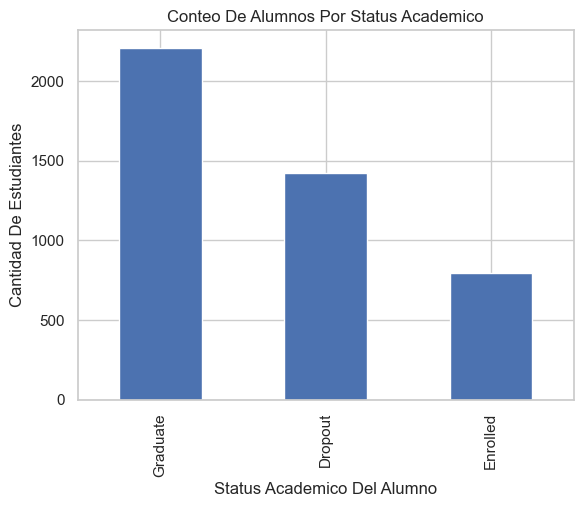

In [26]:
# TODO: print how many students are in each outcome category ('Target' column).
print(df_raw["Target"].value_counts())

# TODO: print the dropout rate as a percentage.
dropout_rate = df_raw["Target"].value_counts(normalize=True)["Dropout"] * 100
print(f"dropout_rate:{dropout_rate:.2f}%")

# TODO: create a bar chart of the three outcome counts.
# Add title, x-label, y-label.
df_raw["Target"].value_counts().plot(kind="bar")
plt.title("Conteo De Alumnos Por Status Academico")
plt.xlabel("Status Academico Del Alumno")
plt.ylabel("Cantidad De Estudiantes")
plt.show()            


In [27]:
# TODO: check how many missing values exist in each column of df_raw.
print(df_raw.isna().sum())

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

### ✅ TODO - Block 1 observation (fill in after running the cells)

After running the cells above, answer in your own words:

- The dataset has **__4424__** rows and **__37__** columns.
- The Target column has **__3__** categories: Graduate,Dropout and Enrolled
- Missing values: the data set after the review doesn´t have missing values
- The 3 columns most relevant to our questions: Target ,admission grade and  Curricular units 1st sem (approved)

---

## 🔷 Block 2 — Clean and Prepare

### Strategy

With 37 columns, we will:
1. **Select** the 12 columns relevant to your questions (list provided below).
2. **Rename** them to clean `snake_case` names (you write the rename_map).
3. **Check** for nulls and duplicates in your subset.
4. **Create** derived columns: `avg_grade` and `gender_label`.

Document every decision in the log at the end of this block.

In [28]:
# Provided: the 12 columns we need (domain knowledge required to pick these).
columns_to_keep = [
    "Age at enrollment",
    "Gender",
    "Scholarship holder",
    "Admission grade",
    "Displaced",
    "Debtor",
    "Tuition fees up to date",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (grade)",
    "Unemployment rate",
    "GDP",
    "Target",
]

df = df_raw[columns_to_keep].copy()
print(f"Subset: {df.shape[0]} rows × {df.shape[1]} columns")

Subset: 4424 rows × 12 columns


### ✏️ TODO — Rename the columns

Complete the `rename_map` so every column gets a clean `snake_case` name.

**Target names:**
`age`, `gender`, `scholarship`, `admission_grade`, `displaced`, `debtor`,
`tuition_ok`, `grade_sem1`, `grade_sem2`, `unemployment_rate`, `gdp`, `target`

In [29]:
# TODO: complete the rename_map dictionary.
rename_map = {
    "Age at enrollment":                    "age" , # example
    "Gender":                               "gender",
    "Scholarship holder":                   "scholarship",
    "Admission grade":                      "admission_grade",
    "Displaced":                            "displaced",
    "Debtor":                               "debtor",
    "Tuition fees up to date":              "tuition_ok",
    "Curricular units 1st sem (grade)":     "grade_sem1",
    "Curricular units 2nd sem (grade)":     "grade_sem2",
    "Unemployment rate":                    "unemployment_rate",
    "GDP":                                  "gdp",
    "Target":                               "target"
}

# TODO: use a pandas function over df to rename the columns using rename_map
df=df.rename(columns=rename_map)
print("Columns after renaming:", df.columns.tolist())

Columns after renaming: ['age', 'gender', 'scholarship', 'admission_grade', 'displaced', 'debtor', 'tuition_ok', 'grade_sem1', 'grade_sem2', 'unemployment_rate', 'gdp', 'target']


In [30]:
# TODO: print the number of null values per column.
print(f"valores nulos")
print(df.isnull().sum())
# TODO: drop duplicate rows and print how many were removed.
duplicados_eliminados=df.duplicated().sum()
df=df.drop_duplicates()
print(f"filas duplicadas eliminadas:{duplicados_eliminados}")

valores nulos
age                  0
gender               0
scholarship          0
admission_grade      0
displaced            0
debtor               0
tuition_ok           0
grade_sem1           0
grade_sem2           0
unemployment_rate    0
gdp                  0
target               0
dtype: int64
filas duplicadas eliminadas:4


### ✏️ TODO — Create derived columns

1. `avg_grade` = (`grade_sem1` + `grade_sem2`) / 2
2. `gender_label`: map `0` → `"Female"`, `1` → `"Male"` using `.map()`

In [31]:
# TODO: create df["avg_grade"].
df["avg_grade"]=((df["grade_sem1"]+df["grade_sem2"])/2).round(2)

df[["grade_sem1", "grade_sem2", "avg_grade"]] = df[["grade_sem1", "grade_sem2", "avg_grade"]].round(2)

# TODO: create df["gender_label"].
df["gender_label"]=df["gender"].map({0: "female", 1: "male"})

# Verify: print the first 5 rows of the new columns.
print(df[["grade_sem1", "grade_sem2", "avg_grade", "gender_label"]].head(5))

   grade_sem1  grade_sem2  avg_grade gender_label
0        0.00        0.00       0.00         male
1       14.00       13.67      13.83         male
2        0.00        0.00       0.00         male
3       13.43       12.40      12.91       female
4       12.33       13.00      12.67       female


### ✅ TODO — Decision log

Add **at least 4 rows** (the first two are examples).

| Decision | Reason |
|----------|--------|
| Kept 12 of 37 columns | Focus on the three analytical questions |
| Renamed to snake_case | Easier to type; no spaces in column names |
| Checked for null values | Ensure no missing data impacts the statistical calculations |
| Dropped duplicate rows | Cleaned the subset resulting in 0 duplicates removed |
| Created avg_grade column | Combined both semesters to analyze overall academic performance|
| Created gender_label column | Mapped numerical binary categories into human-readable text labels|

In fact i decided additionally and in my opinion try to approximate the values only with 2 decimals to obtain a data simply to visualize when we need to take a decision based in a short table 

---

## 🔷 Block 3 — Analysis and Visualization

### Rules for every chart

1. **Statistic first** — compute and print a number before plotting.
2. **Chart second** — the visualization makes the pattern visible.
3. **Always add:** title, x-label, y-label.
4. **After the chart:** one sentence interpreting what you see.

**Minimum: 4 charts total.**
Use your M8 and M9 notebooks as syntax references.

### Question 1 — What is the dropout rate, and does scholarship help?

In [32]:
# TODO: compute dropout rate overall in percentage as (hint: how many 'Dropout' are in 'target' column).
dropout_rate=round(df["target"].value_counts(normalize=True)["Dropout"].item() * 100, 2)
print(f"El porcentaje total de la columna Dropout es {dropout_rate:.2f}%")

El porcentaje total de la columna Dropout es 32.06%


---

### ✏️ Chart 1 — Outcome distribution

**Question:** How many students dropped out vs graduated vs enrolled?

---

**Before you code**

- **Inputs:** column `target`
- **Output:** printed counts + bar chart
- **Steps:**
  1. Use `.value_counts()` on `df["target"]`.
  2. Print the counts and compute the dropout rate (%).
  3. Create a bar chart with one bar per outcome. Use different colors.
  4. Add title, x-label, y-label.
- **Pattern:** Accumulator (counting per category)

target
Graduate    2209
Dropout     1417
Enrolled     794
Name: count, dtype: int64
El porcentaje total de la columna Dropout es 32.06%


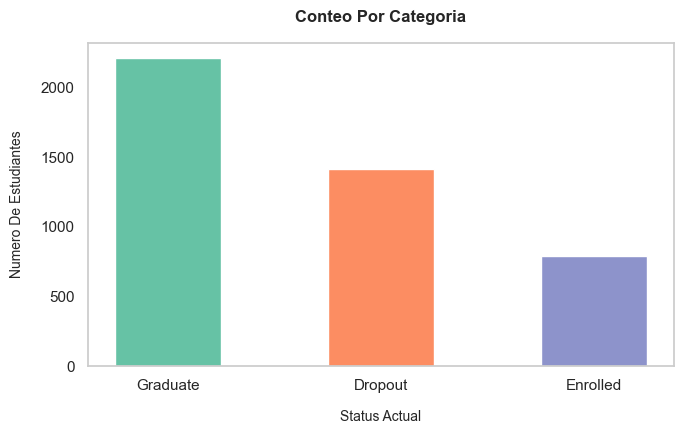

In [33]:
# Chart 1: outcome distribution.

# Step 1-2: statistic first.
# TODO: print outcome counts and dropout rate.
print(df["target"].value_counts())
print(f"El porcentaje total de la columna Dropout es {dropout_rate:.2f}%")

# Step 3-4: bar chart.
plt.figure(figsize=(7, 4.5))
# TODO: create the bar chart.
conteo=(df["target"].value_counts())
plt.bar(conteo.index, conteo.values, color=["#66c2a5", "#fc8d62", "#8d93cbff"], width=0.5)
# TODO: add title, xlabel, ylabel.
plt.title("Conteo Por Categoria", fontsize=12, fontweight="bold", pad=15)
plt.ylim(bottom=0)
plt.xticks(rotation=0)
plt.xlabel("Status Actual", fontsize=10, labelpad=12)
plt.ylabel("Numero De Estudiantes", fontsize=10, labelpad=12)
plt.grid(False)
plt.tight_layout()
plt.show()

---

### ✏️ Chart 2 — Scholarship effect

**Question:** Do students with a scholarship have a lower dropout rate?

---

**Before you code**

- **Inputs:** columns `scholarship` (0=no, 1=yes) and `target`
- **Output:** dropout rate for each group + chart
- **Steps:**
  1. Split `df` into two groups: `scholarship == 0` and `scholarship == 1`.
  2. For each group, compute dropout rate in percentage as: `(target == "Dropout").sum() / len(group) * 100`.
  3. Print both rates.
  4. Create a bar chart comparing the two groups.
  5. Add title, x-label, y-label.
- **Pattern:** Accumulator (computing rate per group)

Dropout rate sin beca: 38.63%
Dropout rate con beca: 12.19%


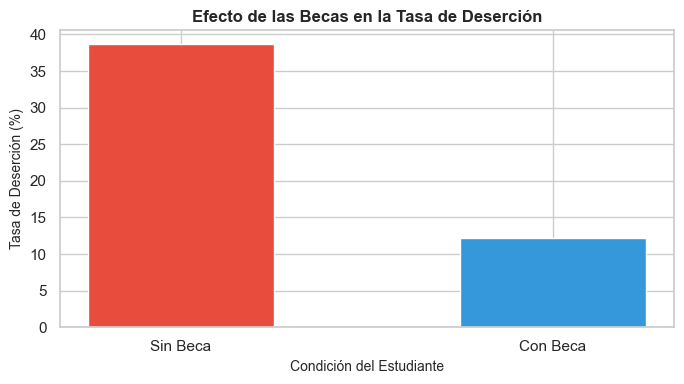

In [ ]:
# Chart 2: scholarship effect on dropout rate.

# Step 1-3: statistic first.
# TODO: compute and print dropout rate for each group.
df_0 = df[df["scholarship"] == 0]
df_1 = df[df["scholarship"] == 1]

rate_0 = (df_0["target"] == "Dropout").sum() / len(df_0) * 100
rate_1 = (df_1["target"] == "Dropout").sum() / len(df_1) * 100

print(f"Dropout rate sin beca: {rate_0:.2f}%")
print(f"Dropout rate con beca: {rate_1:.2f}%")

# Step 4-5: chart.
plt.figure(figsize=(7, 4))
# TODO: bar chart comparing the two groups.
categorias = ["Sin Beca", "Con Beca"]
tasas = [rate_0, rate_1]
barras = plt.bar(categorias, tasas, color=["#e74c3c", "#3498db"], width=0.5)
# TODO: title, xlabel, ylabel.
plt.title(
    "Efecto de las Becas en la Tasa de Deserción", fontsize=12, fontweight="bold")
plt.xlabel("Condición del Estudiante", fontsize=10)
plt.ylabel("Tasa de Deserción (%)", fontsize=10)
plt.tight_layout()
plt.show()

# Interpretation: (write one sentence here as a comment)
# Podemos observar que hay una mayor tasa de desercion en los estudiantes que no tienen beca y es normal ya que en el contexto cultural
# es mas complejo sostener la motivacion para continuar los estudios academicos  sin tener algun tipo de ayuda economica 

---

### ✏️ Chart 3 — Academic performance by outcome

**Question:** Do students who graduate have higher first-semester grades than dropouts?

---

**Before you code**

- **Inputs:** columns `grade_sem1` and `target`
- **Output:** mean grade per outcome + boxplot
- **Steps:**
  1. Compute the mean grade_sem1 PER outcome ('target') — print the result.
  2. Create a boxplot with seaborn to display this groups.
  3. Add title, x-label, y-label.
  4. Write one sentence interpreting the difference.
- **Pattern:** Accumulator (mean per group)

Calificación promedio por resultado
target
Dropout      7.28
Enrolled    11.13
Graduate    12.64
Name: grade_sem1, dtype: float64
----------------------------------------

grade_sem1           1.000000
avg_grade            0.955080
grade_sem2           0.836555
tuition_ok           0.250364
scholarship          0.167556
admission_grade      0.071943
displaced            0.063798
gdp                  0.054954
unemployment_rate    0.015134
debtor              -0.102164
age                 -0.156196
gender              -0.189353
Name: grade_sem1, dtype: float64


C:\Users\julip\AppData\Local\Temp\ipykernel_17788\575798889.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target", y="grade_sem1", data=df, palette="Set2")


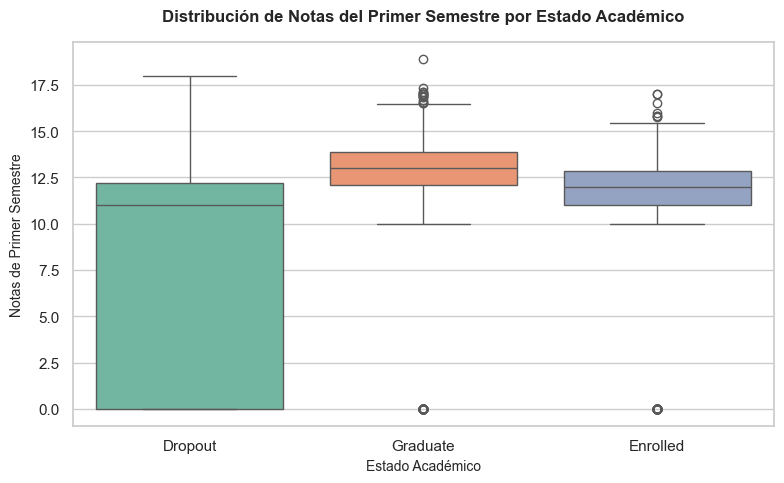

In [50]:
# Chart 3: grade_sem1 distribution by outcome.

# Step 1: statistic first.
# TODO: compute and print mean grade_sem1 per outcome.
means = df.groupby("target")["grade_sem1"].mean().round(2)
print("Calificación promedio por resultado")
print(means)
print("-" * 40)
print()
correlacion_propia = df.corr(numeric_only=True)
print(correlacion_propia["grade_sem1"].sort_values(ascending=False))

# Step 2-3: boxplot.
plt.figure(figsize=(8, 5))
# TODO: sns.boxplot(...)
sns.boxplot(x="target", y="grade_sem1", data=df, palette="Set2")
plt.title(
    "Distribución de Notas del Primer Semestre por Estado Académico",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Estado Académico", fontsize=10)
plt.ylabel("Notas de Primer Semestre", fontsize=10)
plt.tight_layout()
plt.show()

# Interpretation:
# podemos observar que los estudiantes que se graduaron tuvieron un promedio de notas mas alto que los que estan en otros estados academicos
# asimismo podemos observar algunos outliers (datos atipicos) dentro del mismo analisis y podemos observar que es una grafica con una correlacion elevada

---

### ✏️ Chart 4 — Correlation (optional)

**Question:** Does age at enrollment matter?

---

**Before you code**

- **Inputs:** columns ["age", "admission_grade", "grade_sem1", "grade_sem2", "avg_grade", "unemployment_rate", "gdp"]
- **Output:** correlation plot
- **Steps:**
  1. Compute correlation between all columns.
  2. Create a matrix confusion plot (heatmap).
  3. Add title, x-label, y-label.
  4. Write one sentence interpreting the difference.
- **Pattern:** Accumulator (mean per group)

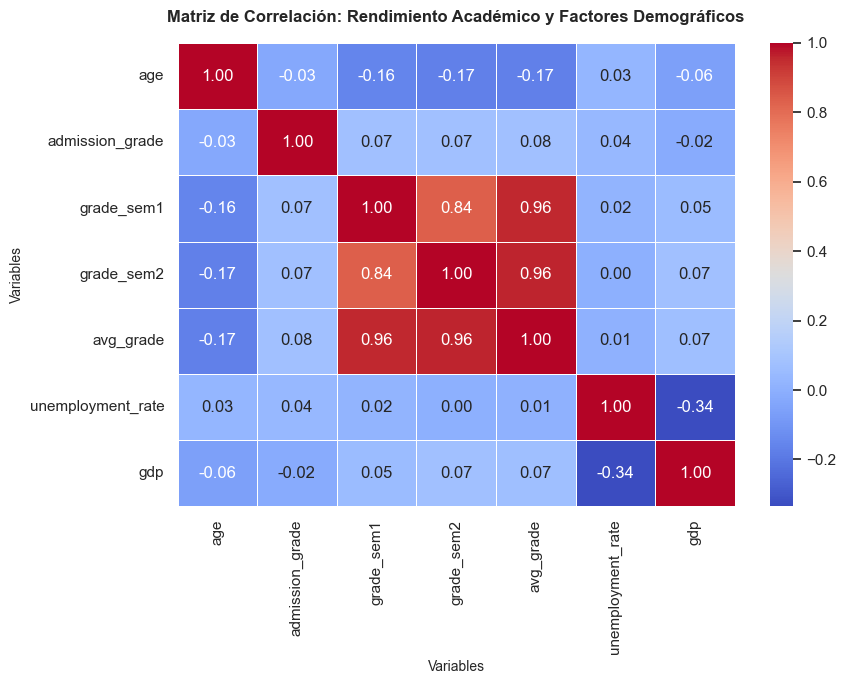

In [51]:
# Chart 4: correlation heatmap of all numeric columns.
numeric_cols = ["age", "admission_grade", "grade_sem1", "grade_sem2",
                "avg_grade", "unemployment_rate", "gdp"]

# TODO: compute correlation and save in 'corr_matrix' variable
corr_matrix = df[numeric_cols].corr()

# TODO: plot heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title(
    "Matriz de Correlación: Rendimiento Académico y Factores Demográficos",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Variables", fontsize=10)
plt.ylabel("Variables", fontsize=10)

plt.tight_layout()
plt.show()

---

### ✏️ Chart 5 — Your own question (required)

Choose any question that interests you. Some ideas:
- Are students with tuition debt (`debtor == 1`) more likely to drop out?
- Does age at enrollment differ between dropouts and graduates?
- Is admission grade correlated with avg_grade? (scatter plot)
- Does the GDP or unemployment rate vary between outcome groups?

**Fill in the plan before writing code.**

**My question:** *(write it here)*

**Columns I will use:** *(list them)*

**Chart type:** *(bar / box / histogram / scatter)*

**Before you code:**
- Inputs: ...
- Output: ...
- Steps:
  1. ...
  2. ...
  3. ...
- Pattern: ...

Tasa de deserción sin deuda: 28.25%
Tasa de deserción con deuda: 61.88%
----------------------------------------


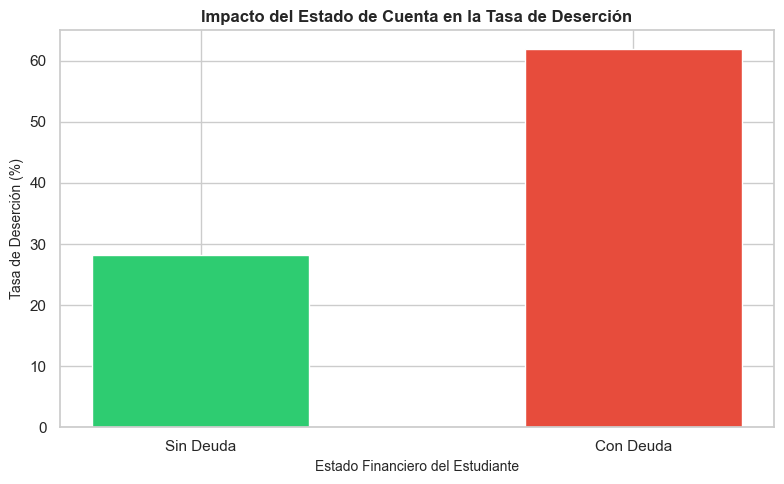

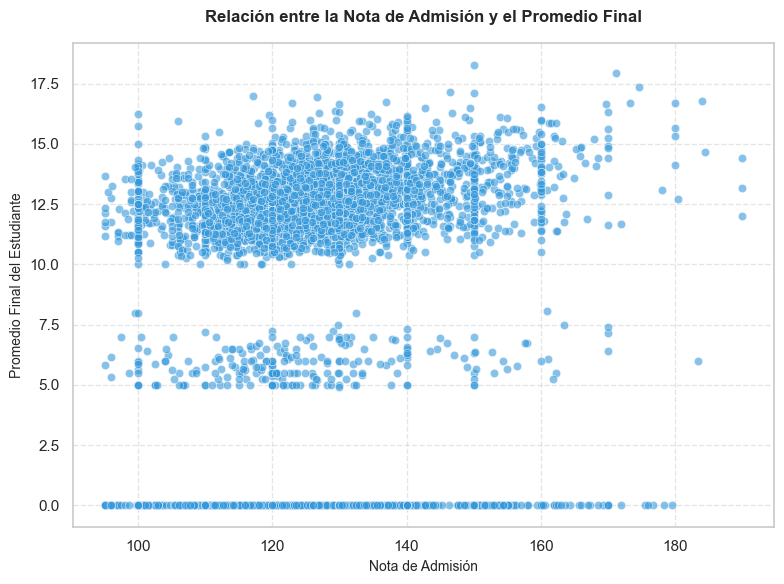

In [ ]:
# Chart 4: your own analysis.

# Statistic first.
# 
#¿Los estudiantes con deudas de matrícula (debtor) presentan una tasa de deserción mayor en comparación con los que están al día?

#columnas que voy a usar : debtor, target

#tipo de cuadro: barras
df_sin_deuda = df[df["debtor"] == 0]
df_con_deuda = df[df["debtor"] == 1]

rate_sin_deuda = (
    (df_sin_deuda["target"] == "Dropout").sum() / len(df_sin_deuda) * 100
)
rate_con_deuda = (
    (df_con_deuda["target"] == "Dropout").sum() / len(df_con_deuda) * 100
)

print(f"Tasa de deserción sin deuda: {rate_sin_deuda:.2f}%")
print(f"Tasa de deserción con deuda: {rate_con_deuda:.2f}%")
print("-" * 40)

# Chart.
plt.figure(figsize=(8, 5))
categorias = ["Sin Deuda", "Con Deuda"]
tasas = [rate_sin_deuda, rate_con_deuda]
barras = plt.bar(categorias, tasas, color=["#2ecc71", "#e74c3c"], width=0.5)

plt.title(
    "Impacto del Estado de Cuenta en la Tasa de Deserción",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Estado Financiero del Estudiante", fontsize=10)
plt.ylabel("Tasa de Deserción (%)", fontsize=10)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x="admission_grade", y="avg_grade", data=df, color="#3498db", alpha=0.6
)
plt.title(
    "Relación entre la Nota de Admisión y el Promedio Final",
    fontsize=12,
    fontweight="bold",
    pad=15,)
plt.xlabel("Nota de Admisión", fontsize=10)
plt.ylabel("Promedio Final del Estudiante", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


# Interpretation:
# El análisis demuestra que mientras las deudas financieras actúan como un detonante crítico para la deserción (elevando drásticamente la tasa de abandono)
# El éxito académico a largo plazo no está determinado por el desempeño con el que ingresa el estudiante (nota de admisión)
# teniendo en cuenta que es  por su capacidad de mantener la regularidad en sus calificaciones desde el primer semestre. 

---

## 🔷 Block 4 — Written Conclusions

### How to write a good conclusion

Do not just say “the chart shows X”. A good conclusion:
1. **States the finding** — what did you observe?
2. **Quantifies it** — by how much? Use specific numbers from your code.
3. **Interprets it** — what does this mean in real life?
4. **Acknowledges limits** — what can you NOT conclude from this data?

## ✏️ Your conclusions

---

### 1. Dataset overview

*(Describe the dataset in 2–3 sentences. Use numbers.)*

El dataset analizado contiene un total de 88 registros de estudiantes universitarios, diseñado para identificar los factores asociados a la deserción académica y el éxito escolar. El conjunto de datos recopila información a través de múltiples variables numéricas y categóricas, destacando factores demográficos como la edad, condiciones financieras como el estado de deuda, y métricas de rendimiento como las notas del primer y segundo semestre.



### 2. Scholarship effect (Chart 2)

Los estudiantes con beca desertaron en un 12.19%. 
Los estudiantes sin beca desertaron en un 38.63%.

Esta diferencia es altamente significativa, ya que la tasa de deserción de los estudiantes que no cuentan con ayuda financiera es más de tres veces mayor en comparación con quienes sí la tienen. En la vida real, esta brecha se explica por dos factores clave: primero, la beca mitiga el estrés económico y las barreras monetarias que obligan a muchos alumnos a abandonar sus estudios; segundo, mantener el beneficio de la beca exige cumplir con un promedio mínimo, lo que funciona como un incentivo muy fuerte para que el estudiante mantenga un rendimiento constante.

### 3. Academic performance (Chart 3)

Los estudiantes que desertaron tuvieron una nota promedio en el primer semestre de 11.0.
Los estudiantes que se graduaron tuvieron una nota promedio en el primer semestre de 13.0.

Esta marcada diferencia sugiere que las calificaciones obtenidas en el primer semestre funcionan como un indicador predictivo temprano sumamente poderoso para la identificación de alumnos en riesgo. Desde una perspectiva de gestión, esto implica que las instituciones universitarias no necesitan esperar a que finalice el año o la carrera para intervenir; un monitoreo analítico durante las primeras semanas permite desplegar tutorías y planes de acompañamiento oportunos dirigidos específicamente al segmento que muestra las notas iniciales más bajas, optimizando así los recursos de retención.

### 4. Your own finding (Chart 4)

Mi pregunta:  ¿Qué tan fuerte es la relación lineal entre las calificaciones obtenidas en el primer semestre (grade_sem1) y el promedio general acumulado (avg_grade) del estudiante?

¿Que encontre?:Al analizar la matriz de correlación (Cuadro 4), se observa un coeficiente de correlación sobresaliente de 0.96 entre grade_sem1 y avg_grade. Este valor numérico, al estar tan ridículamente cerca de 1.0, demuestra la asociación positiva más fuerte de todo el conjunto de datos.


¿Que significa?: En la vida real, esto significa que el desempeño del primer semestre prácticamente calca o define el promedio final de la carrera. No hay factor demográfico o macroeconómico en el dataset que influya tanto; el éxito a largo plazo se cocina desde los primeros meses, lo que justifica por completo concentrar los recursos institucionales en apoyar a los alumnos apenas pisan la universidad.

### 5. Limitations

los resultados y comportamientos observados (como el impacto de las becas o los criterios de calificación) reflejan un contexto socioeconómico y un sistema educativo europeo específico. Por lo tanto, no se pueden generalizar directamente a instituciones de otras regiones, como América Latina, donde las condiciones de financiamiento, la cultura académica y las causas de deserción pueden ser completamente distintas.

Es muy probable que existan variables omitidas o características previas en esos estudiantes (como una mayor disciplina, mejor preparación escolar o un entorno familiar más estable) que influyen tanto en su capacidad para obtener la beca como en su éxito para culminar los estudios.

Al observar la matriz de correlación (Cuadro 4), se evidencia que variables externas como la tasa de desempleo (unemployment_rate) y el PIB (gdp) muestran coeficientes casi nulos (cercanos a 0.00) frente al rendimiento académico. in embargo, esto representa una limitación en el alcance del modelo; a pesar de contar con una muestra sólida de 4424 registros, el dataset solo mide el estado macroeconómico general del país en ese momento, omitiendo la situación financiera particular y microeconómica del entorno familiar del estudiante, la cual en la vida real sí suele ser un detonante directo para la deserción.


---

## 🟠 Optional · Git/GitHub — Publish as portfolio

> Skip if Git was not activated for your course.

After completing all sections:

```
git add module11/module11_integrated_application_student.ipynb
git commit -m "M11: student dropout EDA — integrated application"
git push origin main
```

Add a description to your `README.md`:
```markdown
## Module 11: Integrated Application
End-to-end EDA on a real educational dataset (4,424 students).
Skills: Pandas, Matplotlib, Seaborn, descriptive statistics.
```

---

## 🟣 Optional · pytest — Validate your cleaned data

> Skip if pytest was not activated for your course.

In [ ]:
# Run after completing Block 2 to verify your cleaning is correct.

assert "avg_grade" in df.columns, "avg_grade column is missing!"
print(f"PASS — avg_grade exists")

assert pd.api.types.is_numeric_dtype(df["avg_grade"]), "avg_grade must be numeric."
print(f"PASS — avg_grade is numeric")

assert (df["avg_grade"] >= 0).all() and (df["avg_grade"] <= 20).all(), \
    "avg_grade has values outside the 0–20 scale!"
print(f"PASS — avg_grade range: [{df['avg_grade'].min():.1f}, {df['avg_grade'].max():.1f}]")

assert df.isna().sum().sum() == 0, "Cleaned dataset still has null values!"
print("PASS — no null values")

assert set(df["target"].unique()) == {"Dropout", "Graduate", "Enrolled"}, \
    f"Unexpected target values: {df['target'].unique()}"
print("PASS — target has 3 correct categories")

print("\nAll assertions passed.")

---

*Delivery: bring `module11_integrated_application_student.ipynb` to the next session.
All cells must run without errors from top to bottom.*